# GEOS Wind Data Exploration

This notebook reads and explores the GEOS FP wind data for particle advection.

In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import json

# Set up plotting style
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## Load the GEOS NetCDF4 file

In [2]:
# Open the GEOS NetCDF4 file
file_path = 'GEOS.fp.asm.tavg3_3d_asm_Nv.20220228_0130.V01.nc4'
dataset = nc.Dataset(file_path, 'r')

print(f"File: {file_path}")
print(f"Format: {dataset.data_model}")
print(f"\nGlobal Attributes:")
for attr in dataset.ncattrs():
    print(f"  {attr}: {dataset.getncattr(attr)}")

File: GEOS.fp.asm.tavg3_3d_asm_Nv.20220228_0130.V01.nc4
Format: NETCDF4

Global Attributes:
  Contact: http://gmao.gsfc.nasa.gov
  History: Original file generated: Mon Feb 28 10:23:27 2022 GMT
  Filename: GEOS.fp.asm.tavg3_3d_asm_Nv.20220228_0130.V01.nc4
  Comment: GMAO filename: f5271_fp.tavg3_3d_asm_Nv.20220228_0130z.nc4
  Source: GEOSadas-5_27_1_p8_OPS experiment_id: f5271_fp
  Conventions: CF-1
  Title: GEOS FP (Forward Processing)
  Institution: NASA Global Modeling and Assimilation Office
  References: http://gmao.gsfc.nasa.gov
  Format: NetCDF-4/HDF-5
  SpatialCoverage: global
  VersionID: 5.27.1
  TemporalRange: 2021-02-25 - ongoing
  ShortName: DFPT3NVASM
  RangeBeginningDate: 2022-02-28
  RangeBeginningTime: 00:00:00.000000
  RangeEndingDate: 2022-02-28
  RangeEndingTime: 03:00:00.000000
  GranuleID: GEOS.fp.asm.tavg3_3d_asm_Nv.20220228_0130.V01.nc4
  ProductionDateTime: Original file generated: Mon Feb 28 10:23:27 2022 GMT
  LongName: GEOS FP 3d time-averaged assimilated st

## Explore Dimensions

In [3]:
print("Dimensions:")
for dim_name, dimension in dataset.dimensions.items():
    print(f"  {dim_name}: {len(dimension)} {'(unlimited)' if dimension.isunlimited() else ''}")

Dimensions:
  lon: 1152 
  lat: 721 
  lev: 72 
  time: 1 (unlimited)


## Explore Variables

In [4]:
print("Variables:")
for var_name in dataset.variables.keys():
    variable = dataset.variables[var_name]
    print(f"\n{var_name}:")
    print(f"  Shape: {variable.shape}")
    print(f"  Dimensions: {variable.dimensions}")
    print(f"  Data type: {variable.dtype}")
    
    # Print key attributes
    if 'long_name' in variable.ncattrs():
        print(f"  Description: {variable.getncattr('long_name')}")
    if 'units' in variable.ncattrs():
        print(f"  Units: {variable.getncattr('units')}")

Variables:

lon:
  Shape: (1152,)
  Dimensions: ('lon',)
  Data type: float64
  Description: longitude
  Units: degrees_east

lat:
  Shape: (721,)
  Dimensions: ('lat',)
  Data type: float64
  Description: latitude
  Units: degrees_north

lev:
  Shape: (72,)
  Dimensions: ('lev',)
  Data type: float64
  Description: vertical level
  Units: layer

time:
  Shape: (1,)
  Dimensions: ('time',)
  Data type: int32
  Description: time
  Units: minutes since 2022-02-28 01:30:00

DELP:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Data type: float32
  Description: pressure_thickness
  Units: Pa

EPV:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Data type: float32
  Description: ertels_potential_vorticity
  Units: K m+2 kg-1 s-1

H:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Data type: float32
  Description: mid_layer_heights
  Units: m

O3:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lo

## Extract Coordinate Variables

In [5]:
# Extract coordinates
lats = dataset.variables['lat'][:]
lons = dataset.variables['lon'][:]
lev = dataset.variables['lev'][:]  # Pressure levels
time = dataset.variables['time'][:]

print(f"Latitude range: {lats.min():.2f} to {lats.max():.2f} ({len(lats)} points)")
print(f"Longitude range: {lons.min():.2f} to {lons.max():.2f} ({len(lons)} points)")
print(f"Pressure levels: {len(lev)} levels")
print(f"  Surface to top: {lev.min():.2f} to {lev.max():.2f} hPa")
print(f"Time steps: {len(time)}")

Latitude range: -90.00 to 90.00 (721 points)
Longitude range: -180.00 to 179.69 (1152 points)
Pressure levels: 72 levels
  Surface to top: 1.00 to 72.00 hPa
Time steps: 1


## Extract Wind Data (U and V components)

GEOS data typically contains:
- U: Eastward wind component (m/s)
- V: Northward wind component (m/s)

In [6]:
# Find wind variables
print("Looking for wind variables...")
wind_vars = [var for var in dataset.variables.keys() 
             if any(x in var.upper() for x in ['U', 'V', 'WIND'])]

print(f"\nWind-related variables: {wind_vars}")

# Check each variable
for var_name in wind_vars:
    var = dataset.variables[var_name]
    print(f"\n{var_name}:")
    print(f"  Shape: {var.shape}")
    print(f"  Dimensions: {var.dimensions}")
    if 'long_name' in var.ncattrs():
        print(f"  Description: {var.getncattr('long_name')}")
    if 'units' in var.ncattrs():
        print(f"  Units: {var.getncattr('units')}")

Looking for wind variables...

Wind-related variables: ['lev', 'EPV', 'QV', 'U', 'V']

lev:
  Shape: (72,)
  Dimensions: ('lev',)
  Description: vertical level
  Units: layer

EPV:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Description: ertels_potential_vorticity
  Units: K m+2 kg-1 s-1

QV:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Description: specific_humidity
  Units: kg kg-1

U:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Description: eastward_wind
  Units: m s-1

V:
  Shape: (1, 72, 721, 1152)
  Dimensions: ('time', 'lev', 'lat', 'lon')
  Description: northward_wind
  Units: m s-1


## Extract Surface-Level Wind Data

We'll extract U and V wind components at the lowest pressure level (closest to surface)

In [7]:
# Common variable names for U and V winds in GEOS
u_var_name = None
v_var_name = None

# Try common naming patterns
for var in dataset.variables.keys():
    var_upper = var.upper()
    if var_upper == 'U' or var_upper == 'UWND' or var_upper == 'U10M':
        u_var_name = var
    elif var_upper == 'V' or var_upper == 'VWND' or var_upper == 'V10M':
        v_var_name = var

print(f"U wind variable: {u_var_name}")
print(f"V wind variable: {v_var_name}")

if u_var_name and v_var_name:
    u_wind = dataset.variables[u_var_name]
    v_wind = dataset.variables[v_var_name]
    
    print(f"\nU wind shape: {u_wind.shape}")
    print(f"V wind shape: {v_wind.shape}")
    print(f"U wind dimensions: {u_wind.dimensions}")
    print(f"V wind dimensions: {v_wind.dimensions}")
else:
    print("\nCouldn't find U/V wind variables automatically.")
    print("Please check the variables list above and set u_var_name and v_var_name manually.")

U wind variable: U
V wind variable: V

U wind shape: (1, 72, 721, 1152)
V wind shape: (1, 72, 721, 1152)
U wind dimensions: ('time', 'lev', 'lat', 'lon')
V wind dimensions: ('time', 'lev', 'lat', 'lon')


In [8]:
# Extract surface level wind data
if u_var_name and v_var_name:
    # Get the data - handle different dimension orders
    u_data = dataset.variables[u_var_name][:]
    v_data = dataset.variables[v_var_name][:]
    
    # Check dimensions and extract appropriately
    print(f"Original U data shape: {u_data.shape}")
    print(f"Original V data shape: {v_data.shape}")
    
    # Assume dimensions are (time, lev, lat, lon) or (time, lat, lon)
    if len(u_data.shape) == 4:  # (time, lev, lat, lon)
        # Take first time step and surface level (last level = highest pressure = surface)
        u_surface = u_data[0, -1, :, :]
        v_surface = v_data[0, -1, :, :]
        print(f"Using pressure level: {lev[-1]:.2f} hPa (surface)")
    elif len(u_data.shape) == 3:  # (time, lat, lon)
        u_surface = u_data[0, :, :]
        v_surface = v_data[0, :, :]
        print("Using 2D wind field (no pressure levels)")
    else:
        u_surface = u_data
        v_surface = v_data
    
    print(f"\nSurface wind data shape: {u_surface.shape}")
    print(f"U wind range: {np.nanmin(u_surface):.2f} to {np.nanmax(u_surface):.2f} m/s")
    print(f"V wind range: {np.nanmin(v_surface):.2f} to {np.nanmax(v_surface):.2f} m/s")
    
    # Calculate wind speed
    wind_speed = np.sqrt(u_surface**2 + v_surface**2)
    print(f"Wind speed range: {np.nanmin(wind_speed):.2f} to {np.nanmax(wind_speed):.2f} m/s")
    print(f"Mean wind speed: {np.nanmean(wind_speed):.2f} m/s")

Original U data shape: (1, 72, 721, 1152)
Original V data shape: (1, 72, 721, 1152)
Using pressure level: 72.00 hPa (surface)

Surface wind data shape: (721, 1152)
U wind range: -25.71 to 34.02 m/s
V wind range: -21.66 to 30.87 m/s
Wind speed range: 0.00 to 34.08 m/s
Mean wind speed: 7.35 m/s


## Visualize Global Wind Field

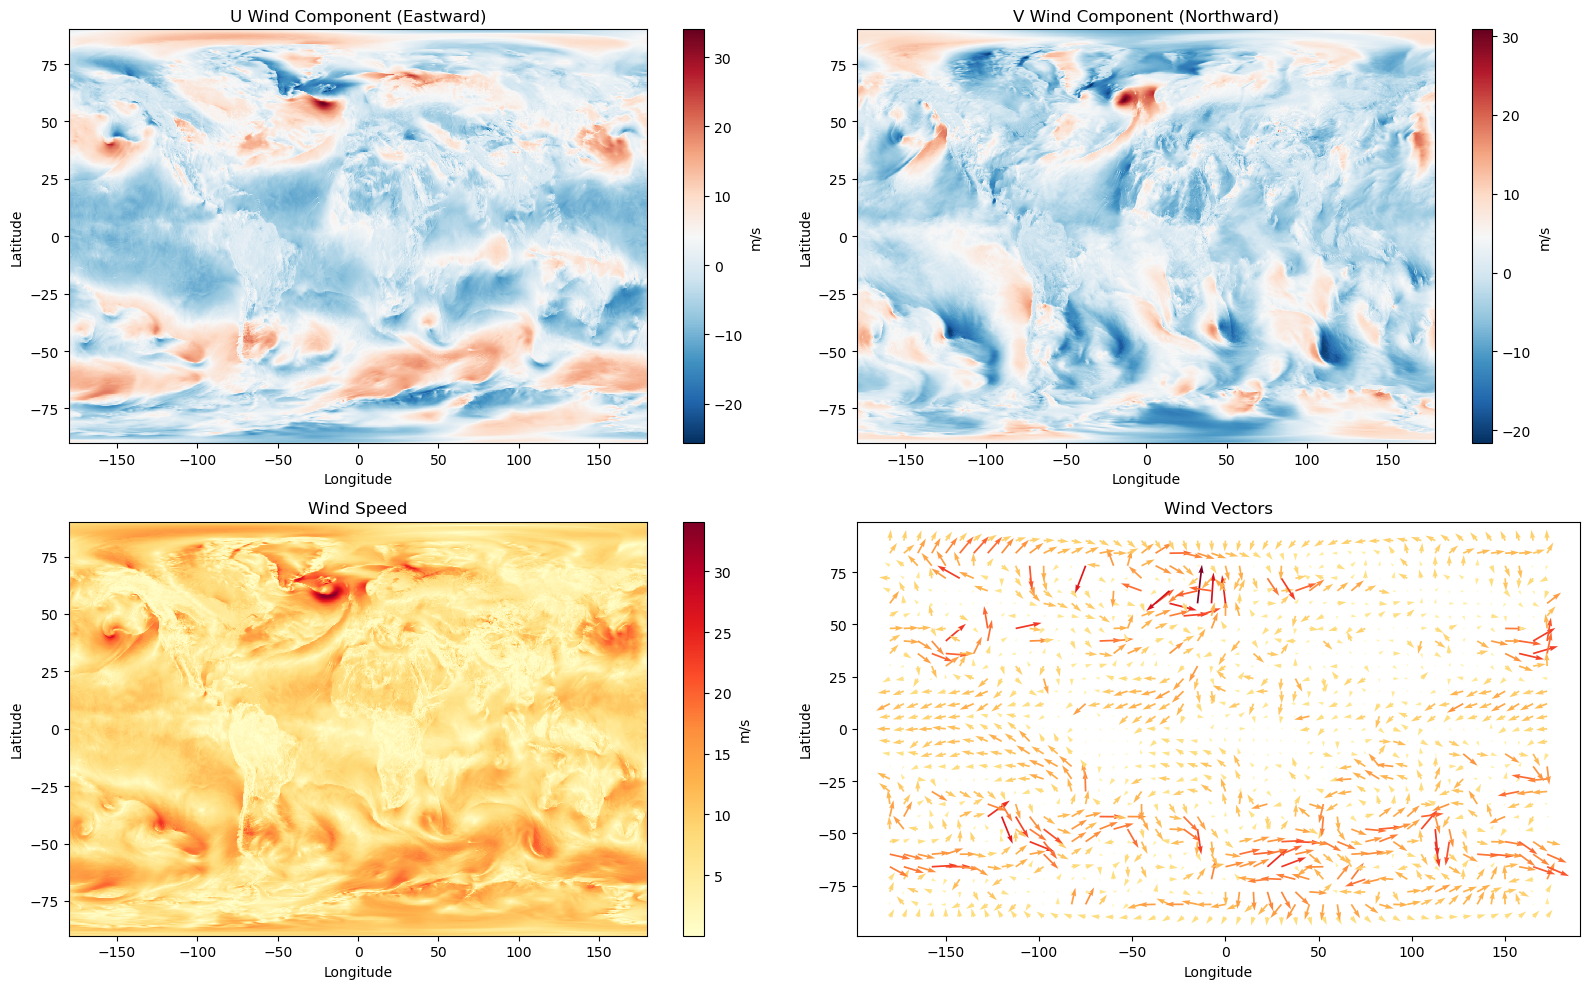

In [9]:
if u_var_name and v_var_name:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Create meshgrid
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Plot U component
    im1 = axes[0, 0].pcolormesh(lon_grid, lat_grid, u_surface, 
                                 cmap='RdBu_r', shading='auto')
    axes[0, 0].set_title('U Wind Component (Eastward)')
    axes[0, 0].set_xlabel('Longitude')
    axes[0, 0].set_ylabel('Latitude')
    plt.colorbar(im1, ax=axes[0, 0], label='m/s')
    
    # Plot V component
    im2 = axes[0, 1].pcolormesh(lon_grid, lat_grid, v_surface, 
                                 cmap='RdBu_r', shading='auto')
    axes[0, 1].set_title('V Wind Component (Northward)')
    axes[0, 1].set_xlabel('Longitude')
    axes[0, 1].set_ylabel('Latitude')
    plt.colorbar(im2, ax=axes[0, 1], label='m/s')
    
    # Plot wind speed
    im3 = axes[1, 0].pcolormesh(lon_grid, lat_grid, wind_speed, 
                                 cmap='YlOrRd', shading='auto')
    axes[1, 0].set_title('Wind Speed')
    axes[1, 0].set_xlabel('Longitude')
    axes[1, 0].set_ylabel('Latitude')
    plt.colorbar(im3, ax=axes[1, 0], label='m/s')
    
    # Plot wind vectors (subsampled for visibility)
    skip = max(1, len(lats) // 30)  # Subsample for arrow plot
    axes[1, 1].quiver(lon_grid[::skip, ::skip], lat_grid[::skip, ::skip],
                      u_surface[::skip, ::skip], v_surface[::skip, ::skip],
                      wind_speed[::skip, ::skip], cmap='YlOrRd', scale=500)
    axes[1, 1].set_title('Wind Vectors')
    axes[1, 1].set_xlabel('Longitude')
    axes[1, 1].set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

## Focus on US Region

US region: 101 x 189 grid points
US U wind range: -9.43 to 17.98 m/s
US V wind range: -12.10 to 19.37 m/s
US wind speed range: 0.01 to 19.50 m/s


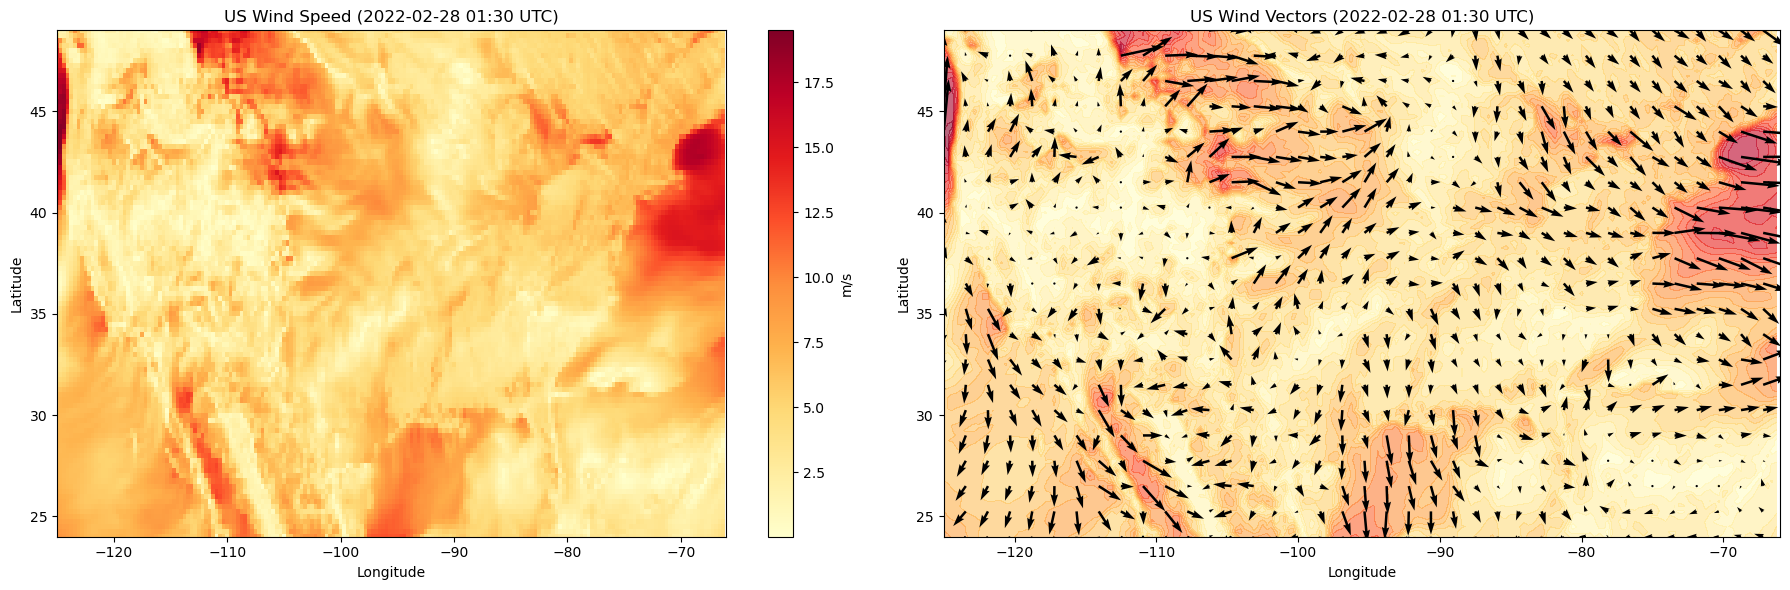

In [10]:
if u_var_name and v_var_name:
    # US bounding box
    us_west, us_east = -125, -66
    us_south, us_north = 24, 49
    
    # Find indices for US region
    lat_mask = (lats >= us_south) & (lats <= us_north)
    lon_mask = (lons >= us_west) & (lons <= us_east)
    
    # Extract US data
    us_lats = lats[lat_mask]
    us_lons = lons[lon_mask]
    us_u = u_surface[np.ix_(lat_mask, lon_mask)]
    us_v = v_surface[np.ix_(lat_mask, lon_mask)]
    us_speed = wind_speed[np.ix_(lat_mask, lon_mask)]
    
    print(f"US region: {len(us_lats)} x {len(us_lons)} grid points")
    print(f"US U wind range: {np.nanmin(us_u):.2f} to {np.nanmax(us_u):.2f} m/s")
    print(f"US V wind range: {np.nanmin(us_v):.2f} to {np.nanmax(us_v):.2f} m/s")
    print(f"US wind speed range: {np.nanmin(us_speed):.2f} to {np.nanmax(us_speed):.2f} m/s")
    
    # Plot US region
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    us_lon_grid, us_lat_grid = np.meshgrid(us_lons, us_lats)
    
    # Wind speed
    im1 = axes[0].pcolormesh(us_lon_grid, us_lat_grid, us_speed, 
                             cmap='YlOrRd', shading='auto')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title('US Wind Speed (2022-02-28 01:30 UTC)')
    axes[0].set_xlim(us_west, us_east)
    axes[0].set_ylim(us_south, us_north)
    plt.colorbar(im1, ax=axes[0], label='m/s')
    
    # Wind vectors
    skip = max(1, len(us_lats) // 20)  # Subsample for visibility
    axes[1].contourf(us_lon_grid, us_lat_grid, us_speed, 
                     levels=20, cmap='YlOrRd', alpha=0.6)
    axes[1].quiver(us_lon_grid[::skip, ::skip], us_lat_grid[::skip, ::skip],
                   us_u[::skip, ::skip], us_v[::skip, ::skip],
                   scale=300, width=0.003)
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title('US Wind Vectors (2022-02-28 01:30 UTC)')
    axes[1].set_xlim(us_west, us_east)
    axes[1].set_ylim(us_south, us_north)
    
    plt.tight_layout()
    plt.show()

## Export Wind Data for deck.gl Visualization

Export the US wind data in JSON format for use in the particle advection visualization

In [11]:
if u_var_name and v_var_name:
    # Prepare data for export
    export_data = {
        'metadata': {
            'date': '2022-02-28',
            'time': '01:30 UTC',
            'source': 'GEOS FP',
            'u_variable': u_var_name,
            'v_variable': v_var_name,
            'units': 'm/s',
            'bounds': {
                'west': float(us_west),
                'east': float(us_east),
                'south': float(us_south),
                'north': float(us_north)
            },
            'grid_size': {
                'width': len(us_lons),
                'height': len(us_lats)
            },
            'wind_stats': {
                'u_range': [float(np.nanmin(us_u)), float(np.nanmax(us_u))],
                'v_range': [float(np.nanmin(us_v)), float(np.nanmax(us_v))],
                'speed_range': [float(np.nanmin(us_speed)), float(np.nanmax(us_speed))],
                'mean_speed': float(np.nanmean(us_speed))
            }
        },
        'lats': us_lats.tolist(),
        'lons': us_lons.tolist(),
        'u': np.nan_to_num(us_u, nan=0.0).tolist(),  # Replace NaN with 0
        'v': np.nan_to_num(us_v, nan=0.0).tolist()   # Replace NaN with 0
    }
    
    # Save to JSON
    output_file = 'wind_data_us.json'
    with open(output_file, 'w') as f:
        json.dump(export_data, f)
    
    print(f"Exported wind data to {output_file}")
    print(f"File contains:")
    print(f"  - Grid: {len(us_lats)} x {len(us_lons)} points")
    print(f"  - U wind: {us_u.shape}")
    print(f"  - V wind: {us_v.shape}")
    print(f"  - Ready for deck.gl particle advection!")

Exported wind data to wind_data_us.json
File contains:
  - Grid: 101 x 189 points
  - U wind: (101, 189)
  - V wind: (101, 189)
  - Ready for deck.gl particle advection!


## Statistics Summary

In [12]:
if u_var_name and v_var_name:
    print("US Wind Data Statistics:")
    print("\nU Component (Eastward):")
    print(f"  Mean: {np.nanmean(us_u):.2f} m/s")
    print(f"  Median: {np.nanmedian(us_u):.2f} m/s")
    print(f"  Std Dev: {np.nanstd(us_u):.2f} m/s")
    print(f"  Min: {np.nanmin(us_u):.2f} m/s")
    print(f"  Max: {np.nanmax(us_u):.2f} m/s")
    
    print("\nV Component (Northward):")
    print(f"  Mean: {np.nanmean(us_v):.2f} m/s")
    print(f"  Median: {np.nanmedian(us_v):.2f} m/s")
    print(f"  Std Dev: {np.nanstd(us_v):.2f} m/s")
    print(f"  Min: {np.nanmin(us_v):.2f} m/s")
    print(f"  Max: {np.nanmax(us_v):.2f} m/s")
    
    print("\nWind Speed:")
    print(f"  Mean: {np.nanmean(us_speed):.2f} m/s")
    print(f"  Median: {np.nanmedian(us_speed):.2f} m/s")
    print(f"  Std Dev: {np.nanstd(us_speed):.2f} m/s")
    print(f"  Min: {np.nanmin(us_speed):.2f} m/s")
    print(f"  Max: {np.nanmax(us_speed):.2f} m/s")

US Wind Data Statistics:

U Component (Eastward):
  Mean: 2.15 m/s
  Median: 1.77 m/s
  Std Dev: 4.13 m/s
  Min: -9.43 m/s
  Max: 17.98 m/s

V Component (Northward):
  Mean: -1.58 m/s
  Median: -1.78 m/s
  Std Dev: 3.83 m/s
  Min: -12.10 m/s
  Max: 19.37 m/s

Wind Speed:
  Mean: 5.44 m/s
  Median: 5.07 m/s
  Std Dev: 3.05 m/s
  Min: 0.01 m/s
  Max: 19.50 m/s


/opt/homebrew/Caskroom/miniconda/base/envs/geoenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


## Close the dataset

In [ ]:
dataset.close()
print("Dataset closed.")